In [ ]:
# Load Libraries and Set Global Variables

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import utils

from chronos import ChronosPipeline
from darts import TimeSeries
from darts.dataprocessing.pipeline import Pipeline
from darts.models import TiDEModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.utils.likelihood_models import QuantileRegression
from darts.dataprocessing.transformers import StaticCovariatesTransformer, MissingValuesFiller

TIME_COL        = "ds"
TARGET          = "mm20"
STATIC_COV      = ["sector", "cap", "region", "asset_id"]
DYNAMIC_COV     = ["market_mm20", "interest_rate", "vix"]
FREQ            = "B"
FORECAST_HORIZON = 10  # business days
SCALER          = Scaler()
TRANSFORMER     = StaticCovariatesTransformer()
PIPELINE        = Pipeline([SCALER, TRANSFORMER])

C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Simulate Financial Data

In [2]:
np.random.seed(42)

n     = 300  # business days (~15 months)
dates = pd.date_range(start="2022-01-01", periods=n, freq="B")

# ── Global dynamic covariates (same for all assets) ──────────────────────────
market_returns      = np.random.normal(0.0003, 0.015, n)
market_prices       = 1000 * np.exp(np.cumsum(market_returns))
market_mm20_series  = pd.Series(market_prices).rolling(20).mean().values

interest_rate_series = 0.05 + np.cumsum(np.random.normal(0, 0.00015, n))
interest_rate_series = np.clip(interest_rate_series, 0.01, 0.15)

vix_series = 20 + np.cumsum(np.random.normal(0, 0.08, n))
vix_series = np.clip(vix_series, 10, 80)

# ── Simulate 16 assets with 4 static covariates ───────────────────────────────
sectors   = ["Tech", "Finance"]
caps      = ["Large", "Small"]
regions   = ["Dom", "Intl"]
asset_ids = ["A", "B"]

records = []
for sector in sectors:
    for cap in caps:
        for region in regions:
            for asset_id in asset_ids:
                drift      = np.random.uniform(0.0005, 0.002)
                volatility = np.random.uniform(0.02, 0.04)
                beta       = np.random.uniform(0.5, 1.5)   # sensitivity to market

                idio_returns  = np.random.normal(drift, volatility, n)
                stock_returns = beta * market_returns + idio_returns

                price0 = np.random.uniform(20, 200)
                prices = price0 * np.exp(np.cumsum(stock_returns))

                records.append(pd.DataFrame({
                    TIME_COL:        dates,
                    "y":             prices,
                    TARGET:          pd.Series(prices).rolling(20).mean().values,
                    "sector":        sector,
                    "cap":           cap,
                    "region":        region,
                    "asset_id":      asset_id,
                    "market_mm20":   market_mm20_series,
                    "interest_rate": interest_rate_series,
                    "vix":           vix_series,
                }))

df = pd.concat(records).dropna().reset_index(drop=True)
df["unique_id"] = df["sector"] + df["cap"] + df["region"] + df["asset_id"]

print(f"Distinct number of time series: {df['unique_id'].nunique()}")
df.head()

Distinct number of time series: 16


,ds,y,mm20,sector,cap,region,asset_id,market_mm20,interest_rate,vix,unique_id
0,2022-01-28,130.547689,141.108461,Tech,Large,Dom,A,1026.744189,0.050826,20.473397,TechLargeDomA
1,2022-01-31,132.816582,141.031748,Tech,Large,Dom,A,1025.213149,0.050841,20.410159,TechLargeDomA
2,2022-02-01,133.212844,140.984902,Tech,Large,Dom,A,1023.620844,0.050930,20.447877,TechLargeDomA
3,2022-02-02,125.039464,140.228959,Tech,Large,Dom,A,1021.586231,0.050807,20.598439,TechLargeDomA
4,2022-02-03,126.013387,139.678173,Tech,Large,Dom,A,1017.345052,0.051121,20.706072,TechLargeDomA


In [ ]:
# Split Data Between Train and Test

In [3]:
unique_dates = sorted(df[TIME_COL].unique())
train_dates  = unique_dates[:-FORECAST_HORIZON]
test_dates   = unique_dates[-FORECAST_HORIZON:]

train = df[df[TIME_COL].isin(train_dates)]
test  = df[df[TIME_COL].isin(test_dates)]

train_darts = TimeSeries.from_group_dataframe(
    df=train,
    group_cols=STATIC_COV,
    time_col=TIME_COL,
    value_cols=TARGET,
    freq=FREQ,
    fill_missing_dates=True,
    fillna_value=0,
)

print(f"Business days for training: {len(train_dates)} from {min(train_dates).date()} to {max(train_dates).date()}")
print(f"Business days for testing:  {len(test_dates)}  from {min(test_dates).date()} to {max(test_dates).date()}")

Business days for training: 271 from 2022-01-28 to 2023-02-10
Business days for testing:  10  from 2023-02-13 to 2023-02-24


In [ ]:
### Create Covariates

In [4]:
dynamic_covariates = []

for serie in train_darts:
    # Month as one-hot encoding, extended to cover the forecast horizon
    covariate = datetime_attribute_timeseries(
        serie,
        attribute="month",
        one_hot=True,
        cyclic=False,
        add_length=FORECAST_HORIZON,
    )

    sv     = serie.static_covariates
    sector = sv["sector"].item()
    cap    = sv["cap"].item()
    region = sv["region"].item()
    aid    = sv["asset_id"].item()

    # Use full df (train + test) so dynamic covariates extend into forecast window
    dyn_cov_df = df[
        (df["sector"]   == sector) &
        (df["cap"]      == cap)    &
        (df["region"]   == region) &
        (df["asset_id"] == aid)
    ]

    dyn_cov_ts = TimeSeries.from_dataframe(
        dyn_cov_df,
        time_col=TIME_COL,
        value_cols=DYNAMIC_COV,
        freq=FREQ,
        fill_missing_dates=True,
    )

    covariate = covariate.stack(MissingValuesFiller().transform(dyn_cov_ts))
    dynamic_covariates.append(covariate)

In [ ]:
# Forecast

In [ ]:
## TiDE

In [5]:
# Scale dynamic covariates and target
dynamic_covariates_transformed = SCALER.fit_transform(dynamic_covariates)
data_transformed               = PIPELINE.fit_transform(train_darts)

TiDE_params = {
    "input_chunk_length":       20,   # look-back: ~1 month of business days
    "output_chunk_length":      FORECAST_HORIZON,
    "num_encoder_layers":       2,
    "num_decoder_layers":       2,
    "decoder_output_dim":       1,
    "hidden_size":              15,
    "temporal_width_past":      4,
    "temporal_width_future":    4,
    "temporal_decoder_hidden":  26,
    "dropout":                  0.1,
    "batch_size":               16,
    "n_epochs":                 15,
    "likelihood":               QuantileRegression(quantiles=[0.25, 0.5, 0.75]),
    "random_state":             42,
    "use_static_covariates":    True,
    "optimizer_kwargs":         {"lr": 1e-3},
    "use_reversible_instance_norm": False,
}

model = TiDEModel(**TiDE_params)
model.fit(data_transformed, future_covariates=dynamic_covariates_transformed, verbose=False)

pred = PIPELINE.inverse_transform(
    model.predict(
        n=FORECAST_HORIZON,
        series=data_transformed,
        future_covariates=dynamic_covariates_transformed,
        num_samples=50,
    )
)

tide_forecast = utils.transform_predictions_to_pandas(pred, TARGET, train_darts, [0.25, 0.5, 0.75])

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_epochs=15` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.16it/s]


In [ ]:
## Chronos

In [6]:
# Load Chronos models (CPU – use device_map="cuda" if GPU is available)
pipeline_tiny = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cpu",
    torch_dtype=torch.float32,
)

pipeline_large = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-large",
    device_map="cpu",
    torch_dtype=torch.float32,
)


def chronos_forecast_fin(model, ts_df, horizon, target):
    """Run Chronos inference and return (lower, mid, upper) quantile arrays."""
    context  = torch.tensor(ts_df[target].tolist())
    forecast = model.predict(context, horizon)
    return np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)


def convert_forecast_fin(forecast, holdout_set, time_col=TIME_COL):
    """Convert quantile arrays to a tidy DataFrame aligned with holdout dates."""
    forecast_pd                  = holdout_set[["unique_id", time_col]].reset_index(drop=True).copy()
    forecast_pd["forecast_lower"] = forecast[0]
    forecast_pd["forecast"]       = forecast[1]
    forecast_pd["forecast_upper"] = forecast[2]
    return forecast_pd


forecast_tiny  = []
forecast_large = []

for ts in train_darts:
    sv        = ts.static_covariates
    unique_id = sv["sector"].item() + sv["cap"].item() + sv["region"].item() + sv["asset_id"].item()
    holdout   = test[test["unique_id"] == unique_id]
    ts_df     = ts.pd_dataframe().reset_index()

    # Tiny
    lower, mid, upper = chronos_forecast_fin(pipeline_tiny, ts_df, FORECAST_HORIZON, TARGET)
    forecast_tiny.append(convert_forecast_fin([lower, mid, upper], holdout))

    # Large (⚠ significantly slower on CPU)
    lower, mid, upper = chronos_forecast_fin(pipeline_large, ts_df, FORECAST_HORIZON, TARGET)
    forecast_large.append(convert_forecast_fin([lower, mid, upper], holdout))

forecast_tiny  = pd.concat(forecast_tiny).reset_index(drop=True)
forecast_large = pd.concat(forecast_large).reset_index(drop=True)

`torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
## Plot Actuals and Forecast

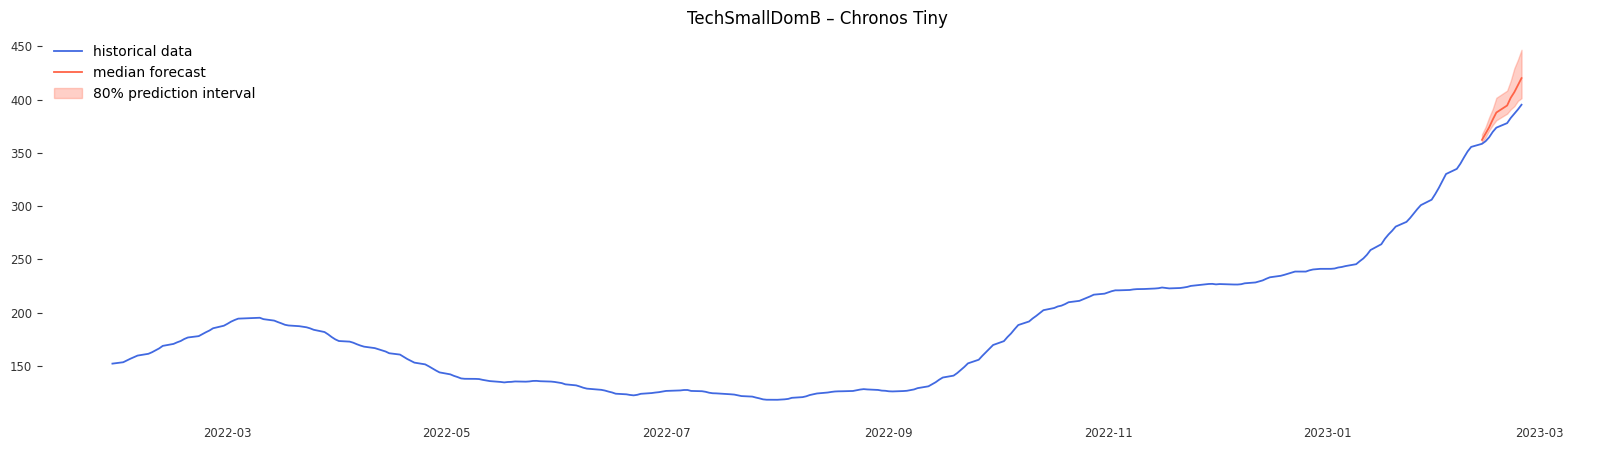

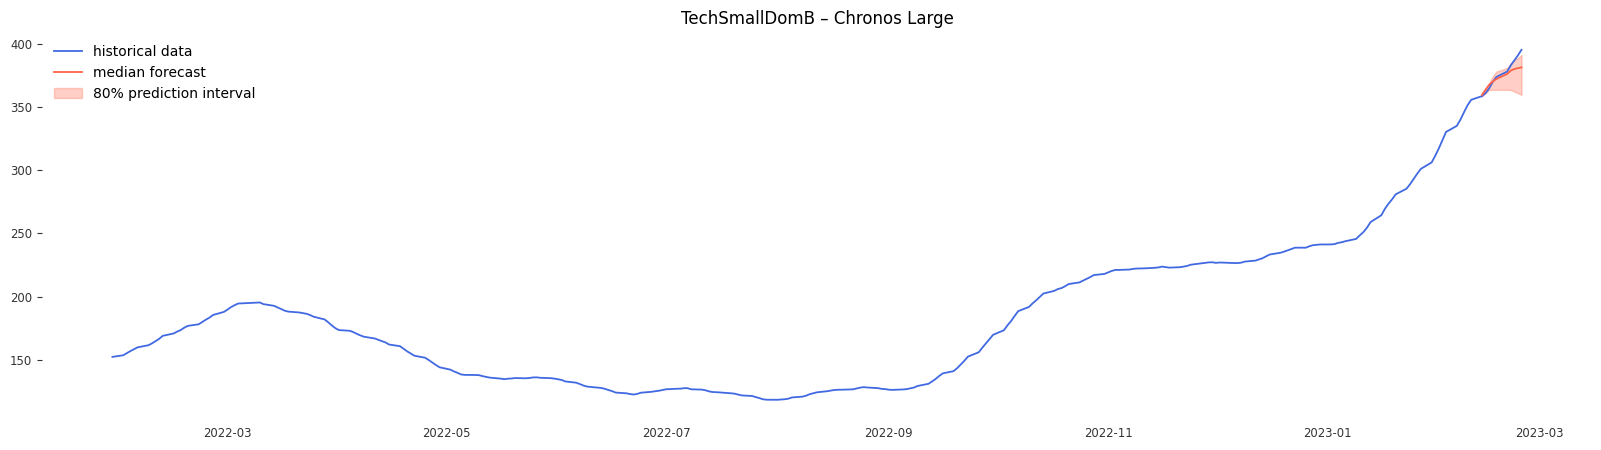

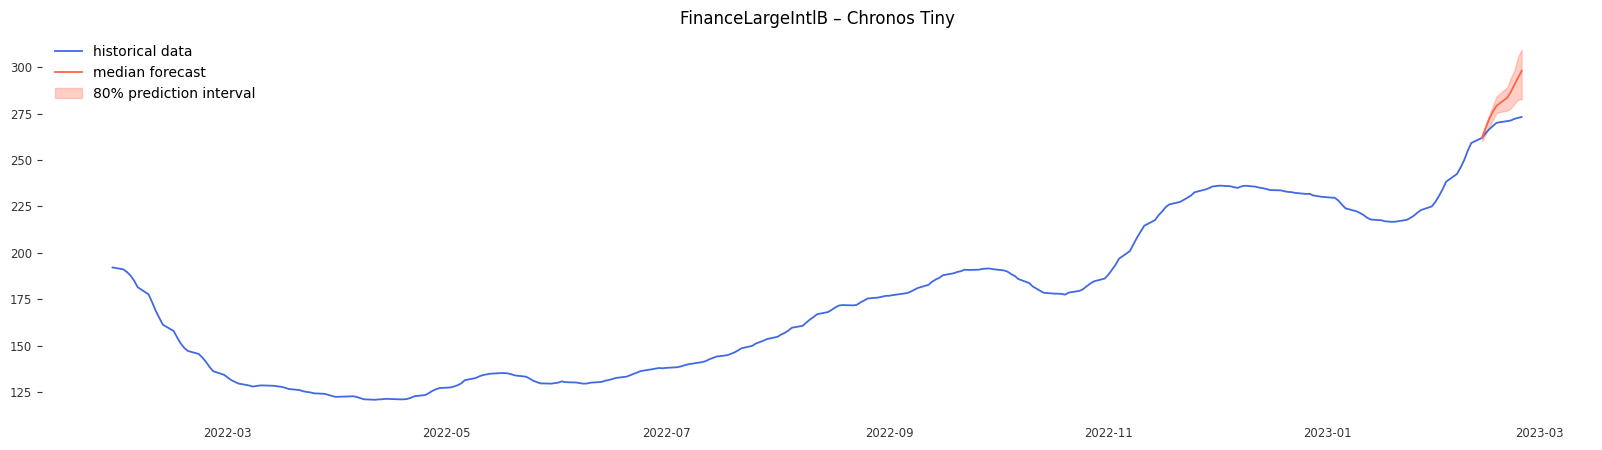

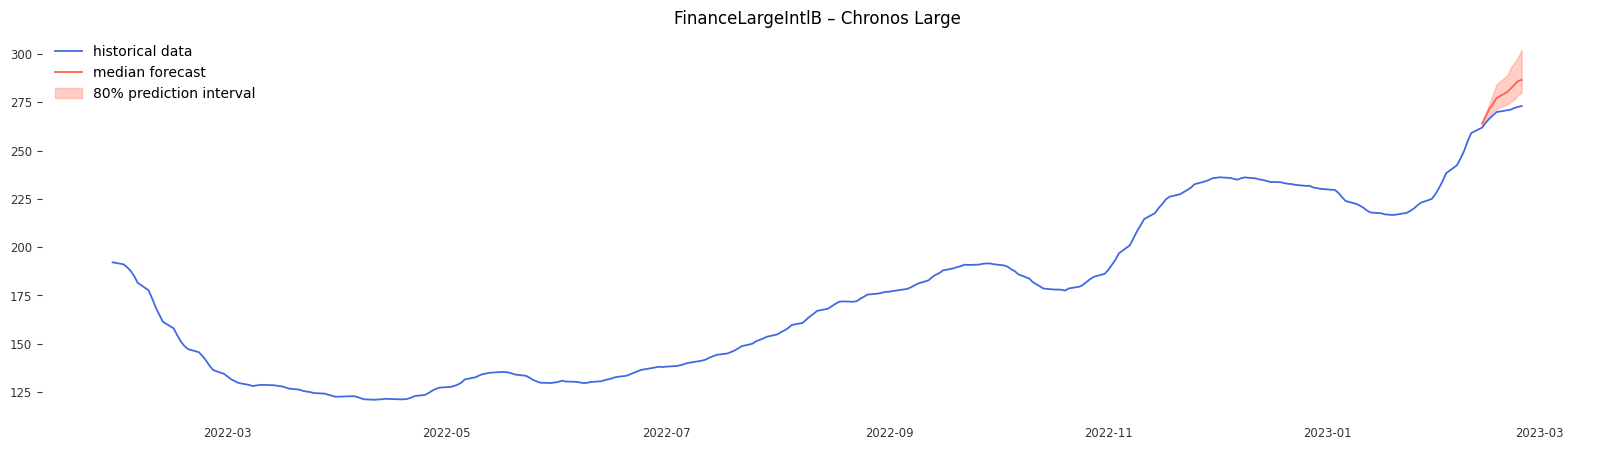

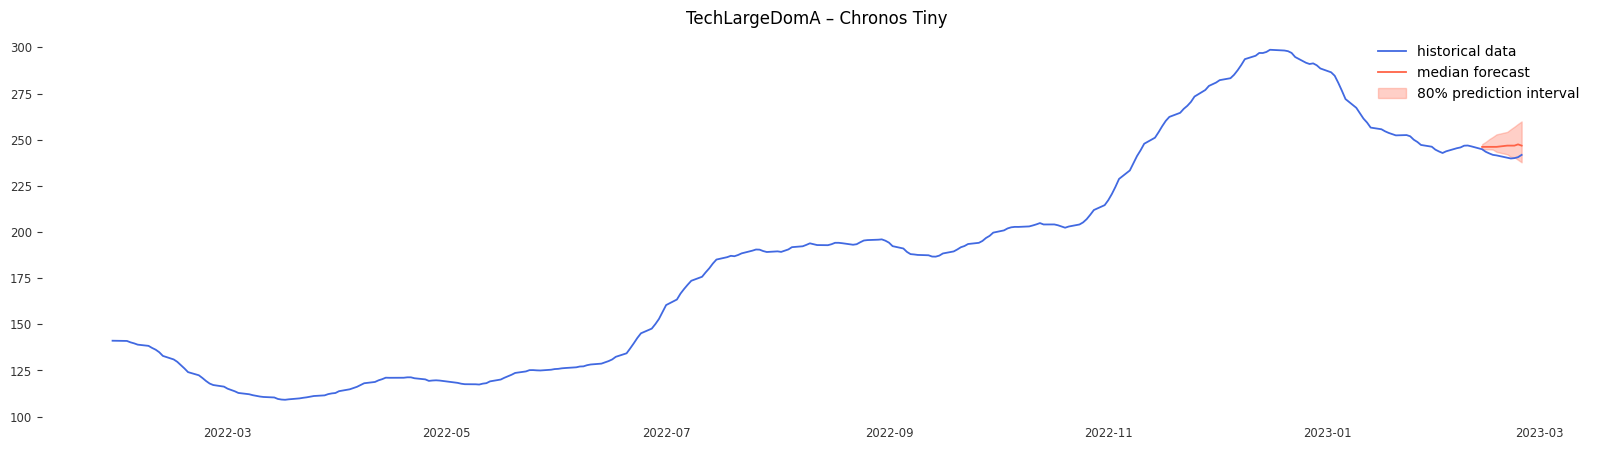

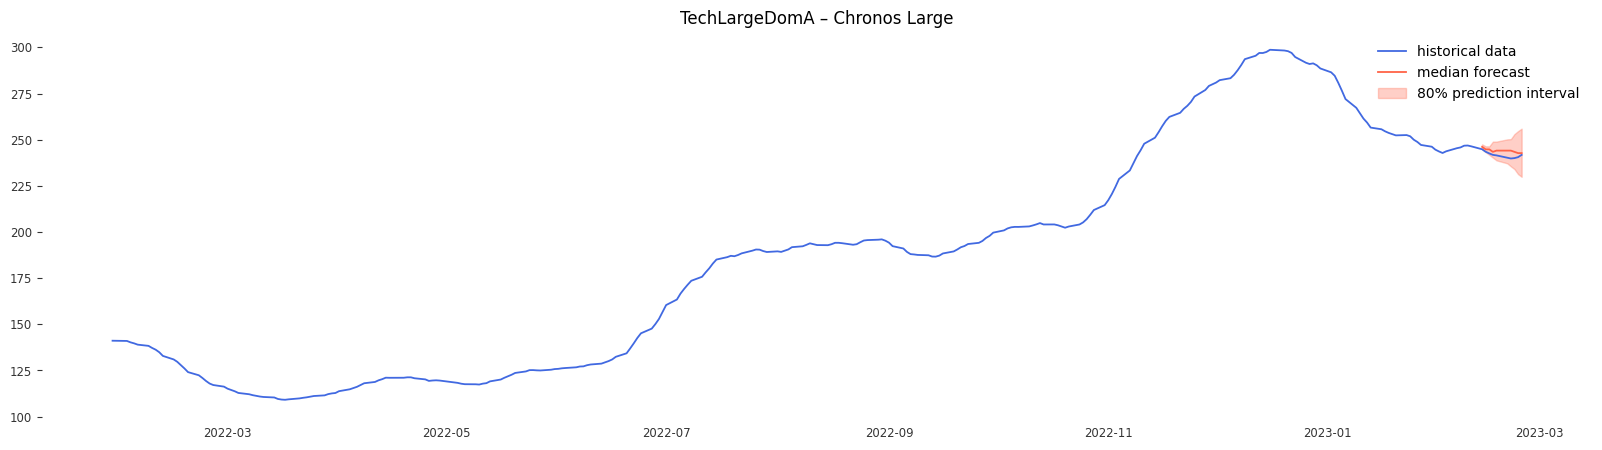

In [7]:
def plot_fin_forecast(actuals, forecast, title, time_col=TIME_COL, target=TARGET):
    plt.figure(figsize=(20, 5))
    plt.plot(actuals[time_col], actuals[target],
             color="royalblue", label="historical data")
    plt.plot(forecast[time_col], forecast["forecast"],
             color="tomato", label="median forecast")
    plt.fill_between(
        forecast[time_col],
        forecast["forecast_lower"],
        forecast["forecast_upper"],
        color="tomato", alpha=0.3, label="80% prediction interval",
    )
    plt.legend()
    plt.grid()
    plt.title(title)
    plt.show()


# Sort assets by total MM20 volume (descending) and plot top 3
series_by_volume = (
    test.groupby("unique_id")[TARGET].sum()
    .reset_index()
    .sort_values(by=TARGET, ascending=False)["unique_id"]
    .tolist()
)

for ts_id in series_by_volume[:3]:
    actuals = df[df["unique_id"] == ts_id]
    plot_fin_forecast(
        actuals,
        forecast_tiny[forecast_tiny["unique_id"] == ts_id],
        f"{ts_id} – Chronos Tiny",
    )
    plot_fin_forecast(
        actuals,
        forecast_large[forecast_large["unique_id"] == ts_id],
        f"{ts_id} – Chronos Large",
    )

In [ ]:
# Model Evaluation

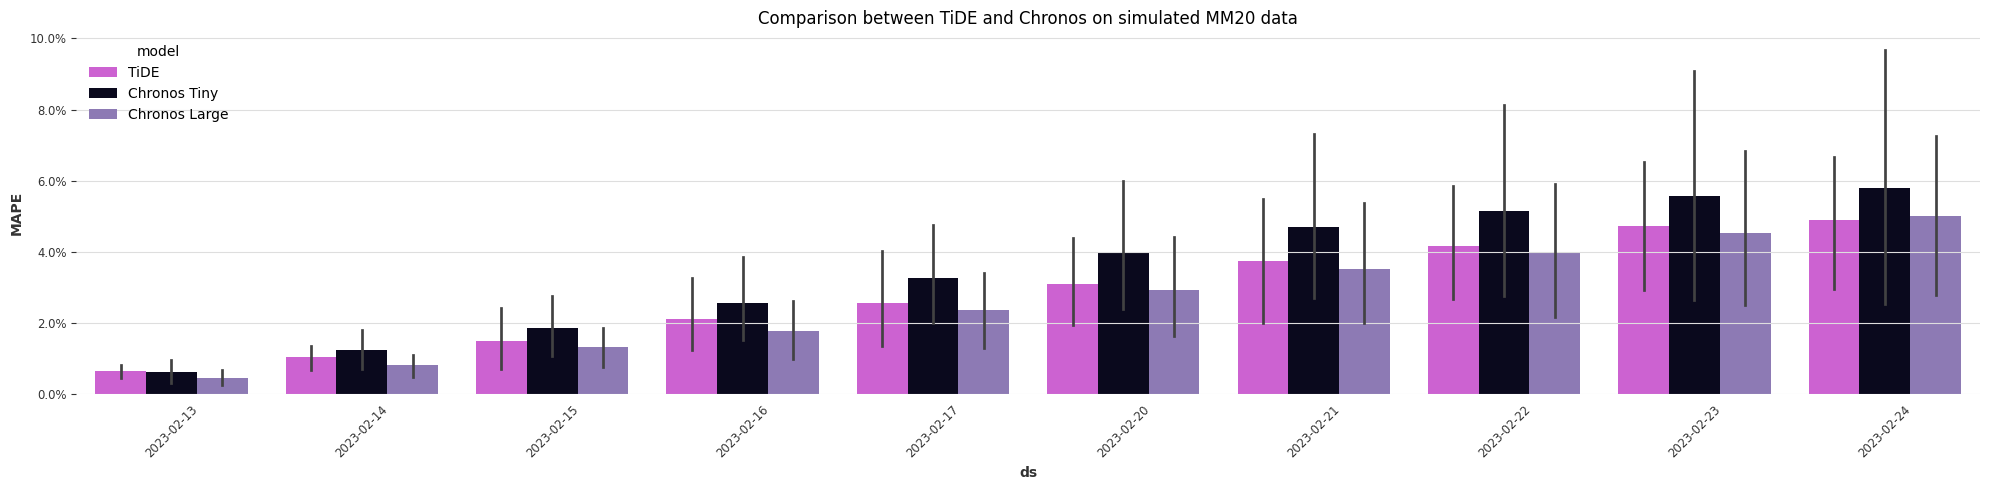

In [8]:
# ── Build unified evaluation DataFrame ───────────────────────────────────────
# TiDE forecast uses utils.transform_predictions_to_pandas which names the time
# column after TIME_COL ("ds"); rename for safety in case Darts uses "time"
tide_time_col = TIME_COL if TIME_COL in tide_forecast.columns else tide_forecast.columns[0]
tide_median   = tide_forecast.rename(columns={tide_time_col: TIME_COL, "forecast": "TiDE"})[
    ["unique_id", TIME_COL, "TiDE"]
]

chronos_tiny_df  = forecast_tiny.rename(columns={"forecast": "Chronos Tiny"})[
    ["unique_id", TIME_COL, "Chronos Tiny"]
]
chronos_large_df = forecast_large.rename(columns={"forecast": "Chronos Large"})[
    ["unique_id", TIME_COL, "Chronos Large"]
]

model_eval_df = test[["unique_id", TIME_COL, TARGET]].copy()
model_eval_df = pd.merge(model_eval_df, tide_median,       on=["unique_id", TIME_COL], how="inner")
model_eval_df = pd.merge(model_eval_df, chronos_tiny_df,  on=["unique_id", TIME_COL], how="inner")
model_eval_df = pd.merge(model_eval_df, chronos_large_df, on=["unique_id", TIME_COL], how="inner")

# ── Top 8 series by volume ────────────────────────────────────────────────────
top_series = (
    df.groupby("unique_id").agg({TARGET: "sum"})
    .reset_index()
    .sort_values(by=TARGET, ascending=False)
    .head(8)
)
eval_top = model_eval_df[model_eval_df["unique_id"].isin(top_series["unique_id"])].copy()

# ── Compute MAPE and melt for plotting ────────────────────────────────────────
for col in ["TiDE", "Chronos Tiny", "Chronos Large"]:
    eval_top[f"MAPE_{col}"] = (eval_top[TARGET] - eval_top[col]).abs() / eval_top[TARGET]

mape_df = eval_top[[TIME_COL, "MAPE_TiDE", "MAPE_Chronos Tiny", "MAPE_Chronos Large"]].melt(
    id_vars=TIME_COL, var_name="model", value_name="MAPE"
)
mape_df["model"]   = mape_df["model"].str.replace("MAPE_", "", regex=False)
mape_df[TIME_COL]  = pd.to_datetime(mape_df[TIME_COL]).dt.date

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.rcParams["figure.figsize"] = (20, 5)
ax = sns.barplot(
    data=mape_df,
    x=TIME_COL,
    y="MAPE",
    hue="model",
    palette=["#dd4fe4", "#070620", "#8a70be"],
)
plt.title("Comparison between TiDE and Chronos on simulated MM20 data")
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()